# Insurance Claim Prediction
Machine Learning mini-project: classify whether a policy results in an insurance claim (`insuranceclaim`).

## Task 1. Dataset Understanding

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("insurance2.csv")

First 5 records

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


Last 5 records

In [4]:
data.tail()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
1333,50,1,30.97,3,0,1,10600.5483,0
1334,18,0,31.92,0,0,0,2205.9808,1
1335,18,0,36.85,0,0,2,1629.8335,1
1336,21,0,25.80,0,0,3,2007.9450,0
1337,61,0,29.07,0,1,1,29141.3603,1


Number of rows and columns

In [5]:
data.shape

(1338, 8)

Column names

In [6]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'insuranceclaim'],
      dtype='object')

Data types

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   int64  
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   int64  
 5   region          1338 non-null   int64  
 6   charges         1338 non-null   float64
 7   insuranceclaim  1338 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 83.8 KB


Missing values

In [8]:
data.isna().sum()

age               0
sex               0
bmi               0
children          0
smoker            0
region            0
charges           0
insuranceclaim    0
dtype: int64

Target balance check

In [9]:
data['insuranceclaim'].value_counts()

insuranceclaim
1    783
0    555
Name: count, dtype: int64

### Questions to Answer
1. **Numerical variables:** age, bmi, children, charges (all continuous/count values).
2. **Categorical variables:** sex, smoker, region, insuranceclaim (already label-encoded as integers in this dataset, but conceptually categorical).
3. **Target variable:** insuranceclaim (binary: 1 = claim made, 0 = no claim).
4. **Is the target balanced?** Check the `value_counts()` output above — the two classes are reasonably close (roughly 55/45 split), so the target is close to balanced, not severely skewed.

## Task 2. Exploratory Data Analysis (Univariate)

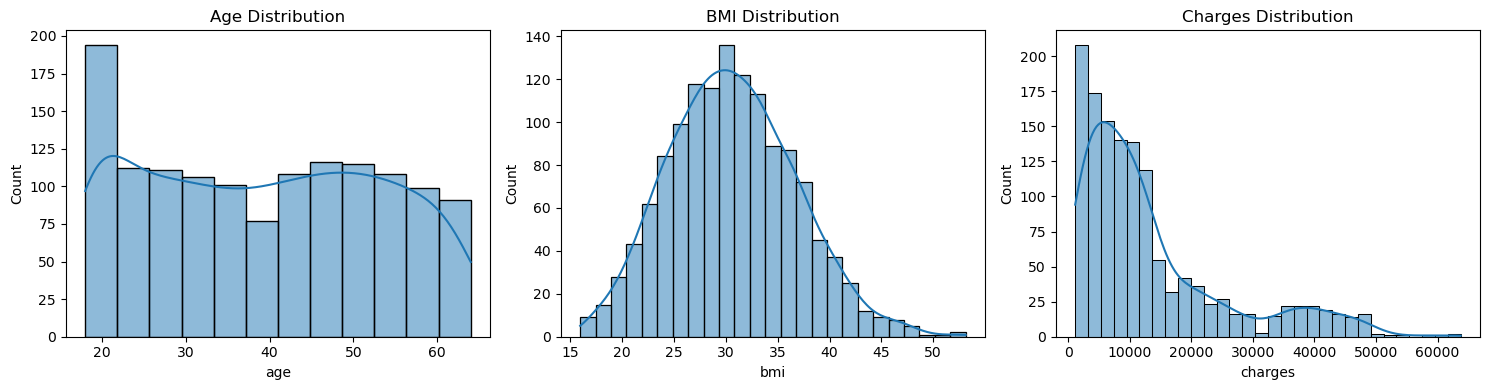

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data['age'], kde=True, ax=axes[0]).set_title('Age Distribution')
sns.histplot(data['bmi'], kde=True, ax=axes[1]).set_title('BMI Distribution')
sns.histplot(data['charges'], kde=True, ax=axes[2]).set_title('Charges Distribution')
plt.tight_layout()
plt.show()

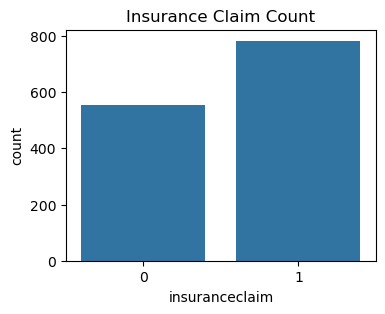

In [11]:
plt.figure(figsize=(4, 3))
sns.countplot(x='insuranceclaim', data=data)
plt.title('Insurance Claim Count')
plt.show()

## Task 3. Data Preprocessing

Separate independent variables (X) and target (y)

In [12]:
X = data.drop(['insuranceclaim'], axis=1)
y = data['insuranceclaim']

`sex`, `smoker`, and `region` are already numerically encoded in this dataset (check with `data['sex'].unique()`, etc.), so no further categorical encoding step is required.

Train/test split

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

Feature scaling — fit the scaler on the training set only, then transform both sets

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Question
**Why fit preprocessing (scaling, encoding) on the training set only, not the full dataset?**

Fitting a scaler/encoder on the full dataset lets statistics from the test set (mean, std, categories) leak into the transformation used at training time. The model then implicitly "sees" information about the test data before evaluation, so the test accuracy overestimates how the model will perform on truly unseen data. Fitting only on `X_train` and applying that same transform to `X_test` keeps the test set as a genuine stand-in for future, unseen data.

## Task 4. Build the Machine Learning Model

In [15]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [16]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

## Task 5. Model Evaluation

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8619402985074627
Confusion Matrix:
 [[ 92  19]
 [ 18 139]]


# Deep Learning: Improving the Insurance Prediction Model

Having built a traditional ML baseline (Logistic Regression), we now try a feed-forward neural network on the same train/test split to see if it beats the baseline.

## Task 7. Design a Neural Network

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],), name='input_layer'),
    layers.Dense(16, activation='relu', name='hidden_layer_1'),
    layers.Dense(8, activation='relu', name='hidden_layer_2'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

### Architecture documentation
- **Input layer:** 7 neurons (one per feature: age, sex, bmi, children, smoker, region, charges).
- **Hidden layers:** 2 — hidden_layer_1 with 16 neurons, hidden_layer_2 with 8 neurons. Funnel-shaped (16 → 8) since this is a small tabular dataset (~1300 rows, 7 features); a wide/deep network would overfit such little data.
- **Activation functions:** ReLU on both hidden layers (fast, avoids vanishing gradients, standard default for tabular feed-forward nets).
- **Output layer:** 1 neuron with **sigmoid** activation — required for binary classification since it squashes the output to a probability in [0, 1].
- **Optimizer:** Adam (adaptive learning rate, converges quickly without much manual tuning — a sensible default for a small network like this).
- **Loss:** binary_crossentropy (matches the sigmoid output / binary target).
- **Epochs:** 50, with `validation_split=0.2` so we can watch for overfitting during training.

### Question: Why this architecture?
The dataset is small (≈1,300 rows) and tabular with only 7 features, so a deep or wide network isn't justified — it would just memorize the training set. Two modestly-sized hidden layers (16 then 8 neurons) give the model enough capacity to learn non-linear interactions between features (e.g. age × smoker × bmi on claim likelihood) that a linear model like Logistic Regression can't capture, while staying small enough to generalize on this amount of data. ReLU is the standard choice for hidden layers, and sigmoid is required at the output because this is binary classification (predicting insuranceclaim = 0 or 1).

## Task 8. Train the Deep Learning Model

In [ ]:
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

## Task 9. Overfitting and Model Improvement

Plot the training vs validation accuracy/loss curves from `history` to check the fit.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train accuracy')
axes[0].plot(history.history['val_accuracy'], label='val accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train loss')
axes[1].plot(history.history['val_loss'], label='val loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

### Reading the curves
Look at the two plots above:
- **Underfitting** — both train and validation accuracy stay low / loss stays high and flat across epochs (the model never learns the pattern).
- **Properly fitted** — train and validation accuracy rise together and converge to a similar, high value; train and validation loss both fall and roughly track each other.
- **Overfitting** — train accuracy keeps climbing toward ~1.0 (train loss keeps falling) while validation accuracy plateaus or drops and validation loss starts rising after some epoch — the gap between the two curves widens over time.

Compare the two curves from this run and classify the model accordingly. If a widening gap appears, mitigate it with dropout, fewer neurons/epochs, or early stopping.

### Question: What does it mean if training accuracy keeps rising while validation accuracy starts declining?
It's the classic **overfitting** signature. The model is continuing to reduce error on the training data (partly by memorizing noise/specific examples), but that improvement no longer transfers to unseen data — validation performance gets worse as training continues. The right response is to stop training earlier (early stopping at the epoch where validation accuracy/loss was best) or reduce model capacity/add regularization (dropout, L2, fewer neurons) so it generalizes instead of memorizing.

## Task 10. Evaluate the Deep Learning Model

In [ ]:
nn_test_loss, nn_test_accuracy = nn_model.evaluate(X_test_scaled, y_test, verbose=0)
print("Neural Network Test Accuracy:", nn_test_accuracy)

nn_y_pred_proba = nn_model.predict(X_test_scaled).ravel()
nn_y_pred = (nn_y_pred_proba > 0.5).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, nn_y_pred))
print("\nLogistic Regression Accuracy:", accuracy)
print("Neural Network Accuracy:     ", nn_test_accuracy)

# M&A Knowledge Assistant — LangChain RAG with Gemini

A Retrieval-Augmented Generation system that answers questions **only** from the provided M&A Playbook PDF (transaction lifecycle, NDA/confidentiality, due diligence, valuation, reps & warranties, indemnification, risk management, integration planning, TargetCo case study, post-merger integration). No external knowledge sources are used — every answer must come from retrieved chunks of this one document.

In [ ]:
!pip install langchain langchain-community langchain-core pypdf langchain-google-genai faiss-cpu

In [ ]:
import os
os.environ["GEMINI_API_KEY"] = "API"

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model='gemini-3.6-flash')

## Task 12. Load and Process the PDF

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("M&A Playbook_ Comprehensive Guide to Deals and Integration.pdf")
documents = loader.load()

playbook_text = ""
for page in documents:
    playbook_text += page.page_content + '\n'

print("Total Pages:", len(documents))
print(playbook_text[:1000])

Experiment with chunk size/overlap before settling on final values.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

for size, overlap in [(500, 50), (1000, 200), (1500, 300)]:
    splitter = RecursiveCharacterTextSplitter(chunk_size=size, chunk_overlap=overlap)
    n_chunks = len(splitter.split_documents(documents))
    print(f"chunk_size={size:5d}  overlap={overlap:4d}  -> {n_chunks} chunks")

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,   # ~1000 characters per chunk
    chunk_overlap=200, # 200-character overlap between consecutive chunks
)

chunks = text_splitter.split_documents(documents)
print(f"Total number of chunks created: {len(chunks)}")

### Questions
1. **Why is document chunking required?** LLM context windows and embedding models both have size limits, and embedding an entire multi-page PDF as one vector would blur many unrelated topics (NDA, due diligence, valuation, integration...) into a single vague representation. Chunking splits the playbook into small, topically-coherent pieces so each one can be embedded and retrieved precisely for the section a question actually relates to.
2. **What happens if chunks are too small?** Chunks lose surrounding context — e.g. a chunk might contain a clause without the section heading or the preceding sentence that explains it, so retrieval returns fragments that are individually low-signal or ambiguous, and the LLM has to guess at missing context (or answer incompletely).
3. **What happens if chunks are too large?** Each chunk starts mixing multiple topics/sections together, which dilutes the embedding (less precise semantic match) and wastes context-window space with irrelevant text once retrieved, increasing the chance the LLM latches onto the wrong part of the chunk or misses the relevant detail buried inside it.
4. **How did you select the chunk size?** The experiment above compares 500/1000/1500-character chunks (with proportional overlap). 1000 characters with a 200-character overlap was chosen as the middle ground — large enough to keep a clause/paragraph with its immediate context intact, small enough to keep each chunk focused on one topic, and the overlap prevents a sentence from being cut in half at a chunk boundary.

## Task 13. Generate Embeddings

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embedding = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2")

# Quick sanity check on what an embedding looks like
sample_vector = embedding.embed_query(chunks[0].page_content)
print("Embedding dimensions:", len(sample_vector))
print(sample_vector[:10])

### Explanation
1. **What is an embedding?** A dense numeric vector (a list of floats, e.g. hundreds/thousands of dimensions) that represents the *meaning* of a piece of text. Text with similar meaning maps to vectors that are close together in that vector space, even if the wording is completely different.
2. **Why are embeddings required for RAG?** RAG needs to find the chunks of the playbook that are relevant to a user's question, but questions rarely reuse the document's exact wording. Embeddings let retrieval compare meaning instead of exact keywords — the question and the relevant chunk are embedded into the same vector space and matched by closeness, regardless of phrasing.
3. **How does semantic similarity work in retrieval?** Both the user's question and every stored chunk are embedded into vectors. At query time, the retriever computes a similarity/distance measure (FAISS uses distance — smaller is more similar) between the question's vector and every chunk's vector, and returns the top-k closest chunks as the "relevant context" passed to the LLM.

## Task 14. Build a Vector Store

Store the M&A Playbook chunk embeddings in FAISS. This vector store is built **only** from `chunks` (derived solely from the provided PDF) — no other document or source is added to it.

In [ ]:
from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embedding
)

print("Vectors stored:", vector_store.index.ntotal)

## Task 15 & 16. Build the RAG Pipeline with Prompt Engineering

The retriever fetches the top-k most similar chunks; the prompt below forces the LLM to answer strictly from that retrieved context, refuse to hallucinate, and say explicitly when the playbook doesn't cover something.

In [ ]:
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

rag_prompt = ChatPromptTemplate.from_template(
    """
    You are the M&A Knowledge Assistant. Answer the user's question using ONLY the
    retrieved context below, which comes exclusively from the company's M&A Playbook.

    Rules:
    - Do not use any outside knowledge. Do not make anything up.
    - If the answer is not present in the retrieved context, respond exactly with:
      "This information is not available in the M&A Playbook."
    - Keep the answer concise but complete — cover every relevant point found in the context.

    Retrieved context:
    {context}

    Question:
    {question}

    Answer:
    """
)

rag_chain = rag_prompt | llm | StrOutputParser()

In [ ]:
def ask_ma_playbook(question):
    retrieved_docs = retriever.invoke(question)
    context = "\n\n".join(doc.page_content for doc in retrieved_docs)

    answer = rag_chain.invoke({"context": context, "question": question})

    print("QUESTION:", question)
    print("\nANSWER:\n", answer)
    print("\n--- Retrieved source context ---")
    for i, doc in enumerate(retrieved_docs, start=1):
        page = doc.metadata.get("page", "unknown")
        print(f"\n[Source {i} | page {page}]")
        print(doc.page_content[:400])

    return answer

In [ ]:
_ = ask_ma_playbook("What is the due diligence process described in the M&A Playbook?")

In [ ]:
_ = ask_ma_playbook("What role does the TargetCo case study play in illustrating integration planning?")

In [ ]:
# Out-of-scope question to verify the "not available" guard works (no hallucination)
_ = ask_ma_playbook("What was the stock price of Apple in 2024?")